In [1]:
import numpy as np
from pyscf import gto, scf, cc

a = 2 # bond length in a cluster
d = 100 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 8 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'H'
basis = 'sto6g'
# for nc in nc_list:
atoms = ""
for n in range(nc * na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
mol = gto.M(atom=atoms,basis=basis,spin=spin*nc,unit=unit,verbose=4)

mf = scf.RHF(mol)
mf.kernel()
print(f"RHF  energy: {mf.e_tot:.10f} Ha")

mycc = cc.CCSD(mf)
mycc.kernel()
print(f"CCSD energy: {mycc.e_tot:.10f} Ha")

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-19-generic', version='#19~24.04.2-Ubuntu SMP PREEMPT_DYNAMIC Fri Mar  6 23:08:46 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Wed Mar 25 14:37:49 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 16
[INPUT] num. electrons = 16
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = b
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 H      0.000000000000   0.000000000000   0.000000000000 AA  

In [2]:
from ad_afqmc_prototype import config
config.configure_once() 
import jax.numpy as jnp

In [3]:
from ad_afqmc_prototype.staging import stage
from ad_afqmc_prototype.staging import StagedMfOrCc
from ad_afqmc_prototype.ham.chol import HamChol

guide_obj = StagedMfOrCc(mycc._scf, norb_frozen=None)
trial_obj = StagedMfOrCc(mycc, norb_frozen=None)

In [4]:
from ad_afqmc_prototype.core.system import System

staged_guide = stage(mycc._scf)
ham = staged_guide.ham
sys = System(norb=int(ham.norb), nelec=ham.nelec, walker_kind="restricted")
ham_data = HamChol(
    jnp.asarray(ham.h0), 
    jnp.asarray(ham.h1), 
    jnp.asarray(ham.chol), 
    basis=ham.basis
    )

In [5]:
# staged_guide = _stage_trial_input(guide_obj)
from ad_afqmc_prototype.trial.rhf import RhfTrial
from ad_afqmc_prototype.trial.pt2ccsd import Pt2ccsdTrial
from ad_afqmc_prototype.staging import _stage_pt2ccsd_input

guide_data = RhfTrial(
    mo_coeff=jnp.array(staged_guide.trial.data['mo'][:,:sys.nup]),
    )

staged_trial = _stage_pt2ccsd_input(trial_obj)

trial_data = Pt2ccsdTrial(
    mo_t = staged_trial.data["mo_t"],
    t2 = staged_trial.data["t2"],
    )

In [6]:
from ad_afqmc_prototype.meas.pt2ccsd import Pt2ccsdMeasCfg, build_meas_ctx

trial_cfg      = Pt2ccsdMeasCfg(memory_mode="low")
trial_meas_ctx = build_meas_ctx(ham_data, trial_data, trial_cfg)

print(trial_meas_ctx)

Pt2ccsdMeasCtx(cfg=Pt2ccsdMeasCfg(memory_mode='low', mixed_real_dtype=<class 'jax.numpy.float64'>, mixed_complex_dtype=<class 'jax.numpy.complex128'>, mixed_real_dtype_testing=<class 'jax.numpy.float32'>, mixed_complex_dtype_testing=<class 'jax.numpy.complex64'>))


In [7]:
from ad_afqmc_prototype.trial.rhf import make_rhf_trial_ops
from ad_afqmc_prototype.meas.rhf  import make_rhf_meas_ops
from ad_afqmc_prototype.prop.afqmc import make_prop_ops, init_prop_state
from ad_afqmc_prototype.meas.pt2ccsd import make_pt2ccsd_meas_ops
from ad_afqmc_prototype.prop.types import QmcParams

guide_ops = make_rhf_trial_ops(sys)
guide_meas_ops  = make_rhf_meas_ops(sys)
guide_prop_ops  = make_prop_ops(ham_data.basis, sys.walker_kind)
trial_meas_ops  = make_pt2ccsd_meas_ops(sys, mixed_precision=False)

params = QmcParams(
    dt            = 0.005,   # imaginary-time step
    n_walkers     = 300,      # walker population
    n_prop_steps  = 50,      # propagation steps per block
    n_blocks      = 200,     # sampling blocks
    n_eql_blocks  = 50,      # equilibration blocks (discarded)
    seed          = 17,
)

print(f"dt={params.dt}  n_walkers={params.n_walkers}  n_prop_steps={params.n_prop_steps}")
print(f"equlibrium imaginary time: {params.n_eql_blocks * params.n_prop_steps * params.dt:.2f} a.u.")
print(f"sampling imaginary time: {params.n_blocks * params.n_prop_steps * params.dt:.2f} a.u.")

dt=0.005  n_walkers=300  n_prop_steps=50
equlibrium imaginary time: 12.50 a.u.
sampling imaginary time: 50.00 a.u.


In [8]:
from ad_afqmc_prototype.driver import run_mixed_qmc
from ad_afqmc_prototype.prop.blocks import block_mixed

mixed_samples = run_mixed_qmc(
                    sys=sys,
                    params=params,
                    ham_data = ham_data,
                    guide_data = guide_data,
                    guide_ops = guide_ops,
                    guide_prop_ops = guide_prop_ops,
                    guide_meas_ops = guide_meas_ops,
                    trial_data = trial_data,
                    trial_meas_ops = trial_meas_ops,
                    mix_block_fn = block_mixed,
                )


Equilibration:

        block   1/Tmp     Guide_E_blk   Guide_W_blk      Trial_E_blk   Trial_W_blk        nodes      t[s]
[eql    0/50]    0.00   -8.4514390564  3.000000e+02   -8.7685702635  3.000000e+02           0       0.0
[eql   10/50]    2.50   -8.6740214538  3.021804e+02   -8.7779493196  3.021804e+02           0       3.3
[eql   20/50]    5.00   -8.7193932409  3.010256e+02   -8.7709942641  3.010256e+02           0       6.2
[eql   30/50]    7.50   -8.7350964319  3.003750e+02   -8.7677493718  3.003750e+02           0       7.1
[eql   40/50]   10.00   -8.7542437296  3.001490e+02   -8.7671857157  3.001490e+02           0       7.9
[eql   50/50]   12.50   -8.7406004377  2.998467e+02   -8.7695840682  2.998467e+02           0       8.7

Sampling:

        block     Guide_E_avg  Guide_E_err       Guide_W     Trial_E_avg  Trial_E_err       nodes    dt[s/bl]     t[s]
[blk   20/200]   -8.7420677949   2.561e-03  2.998773e+02   -8.7717784453   1.296e-03           0      0.630      12.6
[blk

In [9]:
guide_energies = mixed_samples.guide_block_energies
guide_weights = mixed_samples.guide_block_weights
trial_weights = mixed_samples.trial_block_weights
trial_t2s = mixed_samples.trial_block_t2s
trial_e0s = mixed_samples.trial_block_e0s
trial_e1s = mixed_samples.trial_block_e1s

In [ ]:
from ad_afqmc_prototype.stat_utils import clean_pt2ccsd
trial_ept2s = (ham_data.h0 + trial_e0s + trial_e1s - trial_t2s*trial_e0s).real

(trial_wts_clean, 
trial_t2s_clean, 
trial_e0s_clean, 
trial_e1s_clean) = clean_pt2ccsd(
                                trial_ept2s, 
                                trial_weights, 
                                trial_t2s, 
                                trial_e0s, 
                                trial_e1s, 
                                zeta=20
                                )

the outliers block zeta [497.71764489  60.18777402] | energy [-7.12195702 -8.96797135] weight(real) [303.53094034 301.32541612]


In [20]:
trial_ept2s = (ham_data.h0 + trial_e0s_clean + trial_e1s_clean - trial_t2s_clean*trial_e0s_clean).real

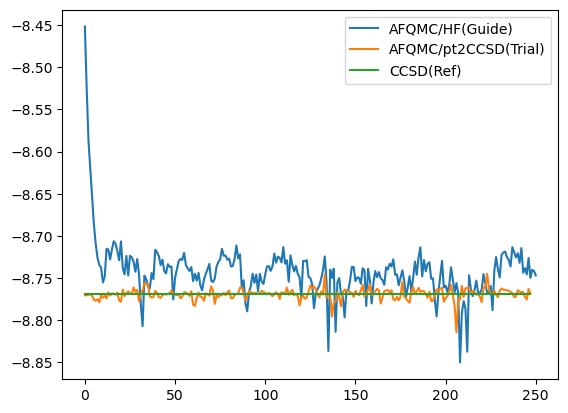

In [24]:
from matplotlib import pyplot as plt
# raw data
plt.plot(guide_energies, label="AFQMC/HF(Guide)")
plt.plot(trial_ept2s, label="AFQMC/pt2CCSD(Trial)")
plt.plot([mycc.e_tot]*len(trial_ept2s), label="CCSD(Ref)")
plt.legend()
plt.show()